2.8.0
[Original] initial loss: 0.30828648805618286
[Original] profile: {'impl': 'Original', 'mode': 'legacy', 'label': 'Original | addFocusPoint+random', 'calls': 142509, 'data_prep_ms': 202324.10966, 'loss_compute_ms': 8802.220573, 'impl_label': 'Original', 'dim': 7, 'sample_size': 101, 'num_sampling_points': 200}
2.8.0
[Optimized] initial loss: 0.30828648805618286
[Optimized] profile: {'impl': 'Optimized', 'mode': 'cached', 'label': 'Optimized | addFocusPoint+random', 'calls': 142509, 'data_prep_ms': 14887.908713, 'loss_compute_ms': 5657.229511, 'impl_label': 'Optimized', 'dim': 7, 'sample_size': 101, 'num_sampling_points': 200}
[Original] calls=142509 | avg data_prep=1.420 ms | avg loss_compute=0.062 ms | avg total=1.481 ms
[Optimized] calls=142509 | avg data_prep=0.104 ms | avg loss_compute=0.040 ms | avg total=0.144 ms


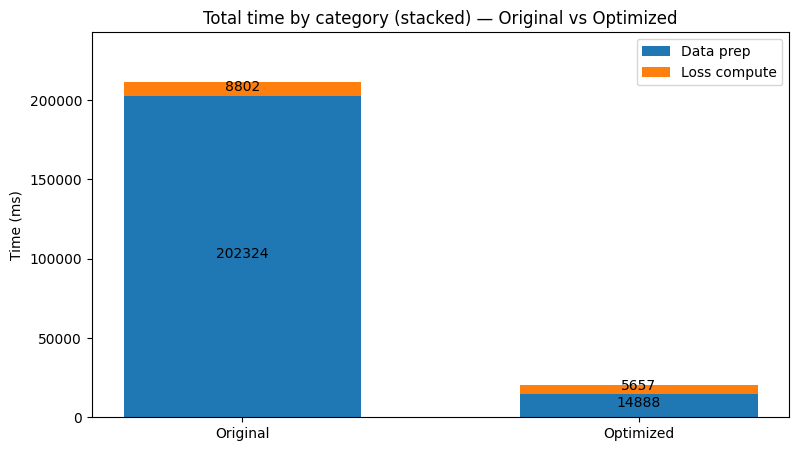

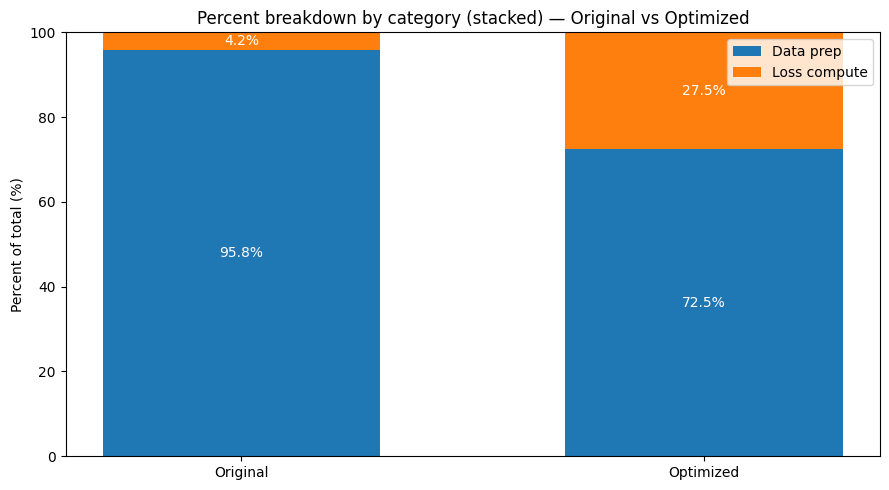

In [1]:
import torch
import torch.nn as nn
from PytorchNetwork import TestNetwork as TestNetworkOrig
from PytorchNetwork import NetworkSlicer as SlicerOrig
from PytorchNetworkOptimized import TestNetwork as TestNetworkOpt
from PytorchNetworkOptimized import NetworkSlicer as SlicerOpt

import math, os, shutil, time
from torch import optim
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime

# --------------------- helpers & config ---------------------

def sinsin(x,y):
    return np.sin(x)+np.sin(y)

def createData(f,size=1024,maxrange=5):
    l = []
    samplesPerDim = int(np.sqrt(size))
    step = maxrange/(samplesPerDim-1)
    for x in range(0,samplesPerDim):
        for y in range(0,samplesPerDim):
            l.append({'x':[x*step,y*step],'y':f(x*step,y*step)})
    return l

def getRandomVector(model,length):
    w = list(np.array(model.getWeights())*0)
    b = list(np.array(model.getBiases())*0)
    wb = w+b
    for i in range(len(wb)):
        wb[i] = np.random.normal()
    wb = wb/np.linalg.norm(wb)*length
    return {'weights':list(wb[:len(w)]),'biases':list(wb[len(w):])}

def reset_seeds(seed=123):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)

# Experiment settings (keep identical across runs)
DATA_SIZE = 1024
MAX_RANGE = 5
NEURONS = 1
LAYER_SHAPE = [2, NEURONS, NEURONS, 1]
DEVICE = torch.device("cpu")
ACTIVATION = "sigmoid"
LOSS_FN = "mse"

MIN_X = -10
MAX_X = 10
NUM_SAMPLING_POINTS = 200
SAMPLE_SIZE = 101

TRAIN_EPOCHS = 10000
TRAIN_LOSS_THRESHOLD = 0.01
TRAIN_MAX_SECONDS = 10
TRAIN_BS = 0
OPTIMIZER = "adam"
LEARNING_RATE = None
WEIGHT_DECAY = 0

# --------------------- one full run ---------------------

def run_experiment(impl_label, TestNetworkCls, SlicerCls, seed_offset=0):
    """
    Builds model + slicer, trains once, runs your loss/slicing pipeline,
    and returns the slicer profiling dict for stacked bar plotting.
    """
    reset_seeds(123 + seed_offset)

    # Generate data
    trainingData = createData(sinsin, DATA_SIZE, MAX_RANGE)
    testData = createData(sinsin, DATA_SIZE, MAX_RANGE)

    # Model
    model = TestNetworkCls(layersShape=LAYER_SHAPE)
    model.device = DEVICE
    model.setActivationFunction(ACTIVATION)
    model.setLossFunction(LOSS_FN)

    # Slicer
    slicer = SlicerCls(model, trainingData, testData)
    slicer.minX = MIN_X
    slicer.maxX = MAX_X

    # Train to get a realistic focus point
    tVec = slicer.getOptimizedFocusPoint(
        epochs=TRAIN_EPOCHS,
        lossThreshold=TRAIN_LOSS_THRESHOLD,
        maxSeconds=TRAIN_MAX_SECONDS,
        bs=TRAIN_BS,
        optimizerType=OPTIMIZER,
        initialWeights=None,
        initialBiases=None,
        learningRate=LEARNING_RATE,
        weightDecay=WEIGHT_DECAY
    )[0]

    # Reset profiling just before the pipeline you want to measure
    slicer.reset_profile(label=f"{impl_label} | addFocusPoint+random")

    # Your pipeline
    w = tVec['weights']
    b = tVec['biases']
    print(f"[{impl_label}] initial loss:", slicer.computeLoss(w, b))

    dim = len(w) + len(b)
    samplingVectors = slicer.getRandomPoints(
        centerFP=tVec,
        quantity=NUM_SAMPLING_POINTS,
        samplingMethod="uniform",
        radius=1
    )

    data = [slicer.addFocusPoint(w, b, SAMPLE_SIZE)]
    for s in samplingVectors:
        data.append(slicer.addFocusPoint(s['weights'], s['biases'], SAMPLE_SIZE))

    prof = slicer.get_profile()
    prof['impl_label'] = impl_label
    prof['dim'] = dim
    prof['sample_size'] = SAMPLE_SIZE
    prof['num_sampling_points'] = NUM_SAMPLING_POINTS

    print(f"[{impl_label}] profile:", prof)
    return prof

# --------------------- run both & visualize ---------------------

if __name__ == "__main__":
    # Run both implementations
    prof_orig = run_experiment("Original", TestNetworkOrig, SlicerOrig, seed_offset=0)
    prof_opt  = run_experiment("Optimized", TestNetworkOpt,  SlicerOpt,  seed_offset=0)

    # Prepare data for stacked bars (absolute ms)
    labels = [prof_orig['impl_label'], prof_opt['impl_label']]
    data_prep_ms = [prof_orig['data_prep_ms'], prof_opt['data_prep_ms']]
    loss_compute_ms = [prof_orig['loss_compute_ms'], prof_opt['loss_compute_ms']]

    x = np.arange(len(labels))
    width = 0.6

    # Absolute times stacked
    fig, ax = plt.subplots(figsize=(9, 5))
    p1 = ax.bar(x, data_prep_ms, width, label='Data prep')
    p2 = ax.bar(x, loss_compute_ms, width, bottom=data_prep_ms, label='Loss compute')

    ax.set_ylabel('Time (ms)')
    ax.set_title('Total time by category (stacked) — Original vs Optimized')
    ax.set_xticks(x, labels)
    ax.legend(loc='upper right')
    ax.bar_label(p1, fmt='%.0f', label_type='center', padding=2)
    ax.bar_label(p2, fmt='%.0f', label_type='center', padding=2)
    ax.set_ylim(0, max(np.add(data_prep_ms, loss_compute_ms)) * 1.15)

    # Percent breakdown stacked
    totals = np.add(data_prep_ms, loss_compute_ms)
    pct_data_prep = [100 * dp / t if t > 0 else 0 for dp, t in zip(data_prep_ms, totals)]
    pct_loss_comp = [100 * lc / t if t > 0 else 0 for lc, t in zip(loss_compute_ms, totals)]

    fig2, ax2 = plt.subplots(figsize=(9, 5))
    p1b = ax2.bar(x, pct_data_prep, width, label='Data prep')
    p2b = ax2.bar(x, pct_loss_comp, width, bottom=pct_data_prep, label='Loss compute')

    ax2.set_ylabel('Percent of total (%)')
    ax2.set_title('Percent breakdown by category (stacked) — Original vs Optimized')
    ax2.set_xticks(x, labels)
    ax2.legend(loc='upper right')
    # Show percentage labels on top of stacks
    for idx, (dp, lc) in enumerate(zip(pct_data_prep, pct_loss_comp)):
        ax2.text(idx, dp/2, f"{dp:.1f}%", ha='center', va='center', color='white')
        ax2.text(idx, dp + lc/2, f"{lc:.1f}%", ha='center', va='center', color='white')
    ax2.set_ylim(0, 100)

    # Optional: print per-call averages (useful debugging)
    for prof in (prof_orig, prof_opt):
        total_ms = prof['data_prep_ms'] + prof['loss_compute_ms']
        calls = max(1, prof['calls'])
        print(
            f"[{prof['impl_label']}] calls={prof['calls']} | "
            f"avg data_prep={prof['data_prep_ms']/calls:.3f} ms | "
            f"avg loss_compute={prof['loss_compute_ms']/calls:.3f} ms | "
            f"avg total={total_ms/calls:.3f} ms"
        )

    plt.tight_layout()
    plt.show()
